# 2장 2강: 퍼널 분석 — 전환율·이탈률 측정 원리 — 실습문제

## 실습 목표

- Ravenstack의 구독 여정을 순차적인 퍼널 단계로 정의할 수 있다.
- 이벤트 횟수와 고유 구독 수의 차이를 설명할 수 있다.
- 단계별 전환율과 이탈률을 계산할 수 있다.
- 막대형 퍼널을 시각화하고 이탈이 집중된 구간을 찾을 수 있다.
- 세그먼트별 퍼널을 비교하고 개선 가설을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

이번 실습에서는 Ravenstack의 구독 여정을 다음과 같이 단순화합니다.

| 순서 | 퍼널 단계 | 집계 기준 |
|---:|---|---|
| 1 | 구독 시작 | `subscriptions`에 존재하는 고유 구독 |
| 2 | 기능 사용 | 기능 사용 기록이 한 번 이상 있는 구독 |
| 3 | 유료 구독 | 기능 사용 구독 중 `is_trial == False`인 구독 |
| 4 | 현재 유료 유지 | 이전 단계 구독 중 `end_date`가 비어 있는 구독 |

> 이 퍼널은 전환율 계산 원리를 익히기 위한 학습용 정의입니다. `is_trial`은 실제 유료 전환 시각을 기록한 이벤트가 아니므로 실제 전환 소요 시간이나 행동 순서를 완전히 재구성할 수는 없습니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 구독 ID의 고유 개수와 기능 사용 이벤트 행 수를 확인하세요.
7. `usage_id`의 중복 개수를 확인하고, 중복 ID를 바로 삭제하면 안 되는 이유를 생각해보세요.

In [2]:
# 실습 준비 코드를 작성하세요.
import pandas as pd
import matplotlib.pyplot as plt

subscriptions = pd.read_csv("C:/Users/jihun/OneDrive/Desktop/DS 실습자료/LV2/프로덕트분석/DATA/1,2,4장/ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("C:/Users/jihun/OneDrive/Desktop/DS 실습자료/LV2/프로덕트분석/DATA/1,2,4장/ravenstack_feature_usage.csv")

print(f"subscriptions 크기: {subscriptions.shape[0]}행, {subscriptions.shape[1]}열")
print(f"feature_usage 크기: {feature_usage.shape[0]}행, {feature_usage.shape[1]}열")

display(subscriptions.head())
display(feature_usage.head())

subscription_cols = [
    "subscription_id", "start_date", "end_date", "plan_tier",
    "billing_frequency", "is_trial"]

usage_cols = ["usage_id", "subscription_id", "usage_date", "feature_name"]

print("\n[subscriptions 자료형과 결측치]")
print(subscriptions[subscription_cols].dtypes)
print(subscriptions[subscription_cols].isna().sum())

print("\n[feature_usage 자료형과 결측치]")
print(feature_usage[usage_cols].dtypes)
print(feature_usage[usage_cols].isna().sum())

subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["end_date"] = pd.to_datetime(subscriptions["end_date"])
feature_usage["usage_date"] = pd.to_datetime(feature_usage["usage_date"])

print(f"\n전체 구독 ID 고유 개수: {subscriptions['subscription_id'].nunique():,}개")
print(f"기능 사용 이벤트 행 수: {len(feature_usage):,}건")
print(f"기능을 사용한 구독 ID 고유 개수: {feature_usage['subscription_id'].nunique():,}개")
print(f"중복 usage_id 수: {feature_usage['usage_id'].duplicated().sum():,}개")

subscriptions 크기: 5000행, 14열
feature_usage 크기: 25000행, 8열


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



[subscriptions 자료형과 결측치]
subscription_id      object
start_date           object
end_date             object
plan_tier            object
billing_frequency    object
is_trial               bool
dtype: object
subscription_id         0
start_date              0
end_date             4514
plan_tier               0
billing_frequency       0
is_trial                0
dtype: int64

[feature_usage 자료형과 결측치]
usage_id           object
subscription_id    object
usage_date         object
feature_name       object
dtype: object
usage_id           0
subscription_id    0
usage_date         0
feature_name       0
dtype: int64

전체 구독 ID 고유 개수: 5,000개
기능 사용 이벤트 행 수: 25,000건
기능을 사용한 구독 ID 고유 개수: 4,967개
중복 usage_id 수: 21개


---

## 필수 1. 전체 구독 퍼널의 전환율과 이탈률 계산하기

### 문제 1-1. Ravenstack 구독은 어느 구간에서 가장 많이 이탈하는가?

#### 문제 설명

전체 Ravenstack 구독을 대상으로 네 단계의 고유 구독 수를 계산하고, 각 구간의 전환율과 이탈률을 구하세요.

각 단계는 반드시 앞 단계를 통과한 구독만 포함해야 합니다. 예를 들어 유료 구독 단계는 전체 유료 구독이 아니라 **기능 사용 단계에 포함되면서 유료인 구독**으로 계산합니다.

#### 요구사항

1. 전체 구독 ID를 `started_ids`로 만드세요.
2. 기능 사용 기록이 있는 구독 ID와 `started_ids`의 교집합을 `used_ids`로 만드세요.
3. `used_ids`와 체험이 아닌 구독 ID의 교집합을 `paid_ids`로 만드세요.
4. `paid_ids`와 종료일이 비어 있는 구독 ID의 교집합을 `retained_paid_ids`로 만드세요.
5. 단계명과 고유 구독 수를 사용하여 `funnel` 데이터프레임을 만드세요.
6. 다음 식으로 구간 전환율과 이탈률을 계산하세요.
   - 전환율 = 현재 단계 구독 수 ÷ 이전 단계 구독 수
   - 이탈률 = 1 - 전환율
7. 각 구간의 이탈 구독 수도 계산하세요.
8. 단계별 구독 수를 막대그래프로 시각화하세요.
9. 전환율이 가장 낮은 구간을 찾고 개선 가설을 한 가지 제안하세요.

#### 해석 질문

**Q1.** 기능 사용 이벤트 행 수 대신 고유 구독 수를 사용해야 하는 이유는 무엇인가요?
-> 같은 구독에서 기능 사용 이벤트가 여러 번 발생할 수 있다.
-> 중복 계산이 될 위험성이 있다.

**Q2.** 전환율이 가장 낮고 이탈 구독 수가 가장 많은 구간은 어디인가요?  
-> 기능 사용 -> 유료 구독 구간, 전환율은 약 84.42%, 이탈 구독 수는 774개

**Q3.** 전환율과 이탈률을 더하면 얼마인가요?  
-> 100%. 이탈율 = 1 - 전환율로 계산

**Q4.** 낮은 전환율만으로 실제 이탈 원인을 확정할 수 있나요?
-> 없다. 퍼널은 사용자가 많이 줄어든 위치를 보여주지만, 
-> 가격, 성능, 기능 부족 등 어떤 이유로 줄었는 지는 원인 파악이 추가적으로 필요하다.

#### 제출 결과

- 단계별 고유 구독 집합
- `funnel` 데이터프레임
- 전환율·이탈률·이탈 구독 수
- 막대형 퍼널
- 이탈 집중 구간과 개선 가설
- Q1~Q4 답변

   stage subscriptions conversion_rate dropoff_rate dropoff_subscriptions
   구독 시작         5,000         100.00%        0.00%                     0
   기능 사용         4,967          99.34%        0.66%                    33
   유료 구독         4,193          84.42%       15.58%                   774
현재 유료 유지         3,788          90.34%        9.66%                   405


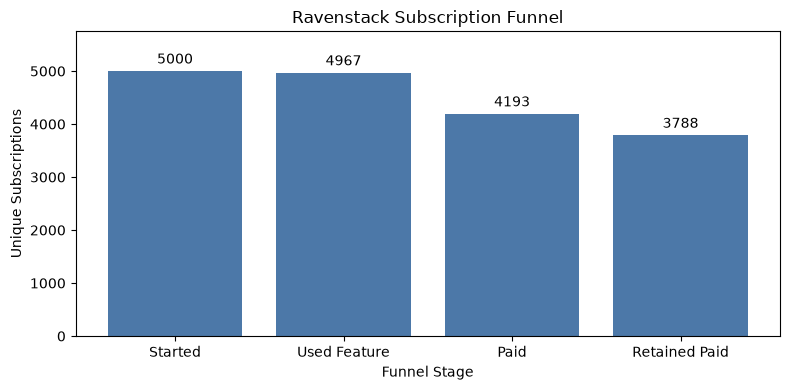


전환율이 가장 낮은 도착 단계: 유료 구독
해당 구간 전환율: 84.42%
해당 구간 이탈률: 15.58%
해당 구간 이탈 구독 수: 774개
개선 가설: 기능 사용 기록이 있는 체험 구독과 비체험 구독의 사용 특성에 차이가 있는지 확인합니다.


In [3]:
# 필수 1 코드를 작성하세요.
started_ids = set(subscriptions["subscription_id"])

usage_ids = set(feature_usage.loc[feature_usage["usage_count"] > 0,"subscription_id"])
used_ids = started_ids & usage_ids

non_trial_ids = set(subscriptions.loc[subscriptions["is_trial"] == False, "subscription_id"])
paid_ids = used_ids & non_trial_ids

not_ended_ids = set(subscriptions.loc[subscriptions["end_date"].isna(), "subscription_id"])
retained_paid_ids = paid_ids & not_ended_ids

funnel = pd.DataFrame({
    "stage": ["구독 시작", "기능 사용", "유료 구독", "현재 유료 유지"],
    "subscriptions": [
        len(started_ids), len(used_ids),
        len(paid_ids), len(retained_paid_ids)]})

funnel["conversion_rate"] = (funnel["subscriptions"] / funnel["subscriptions"].shift(1))
funnel.loc[0, "conversion_rate"] = 1.0
funnel["dropoff_rate"] = 1 - funnel["conversion_rate"]
funnel["dropoff_subscriptions"] = (funnel["subscriptions"].shift(1) - funnel["subscriptions"]).fillna(0).astype(int)

print(funnel.to_string(index=False, formatters={
    "subscriptions": lambda x: f"{x:,.0f}",
    "conversion_rate": lambda x: f"{x:.2%}",
    "dropoff_rate": lambda x: f"{x:.2%}",
    "dropoff_subscriptions": lambda x: f"{x:,.0f}"}))

plt.figure(figsize=(8, 4))
chart_labels = ["Started", "Used Feature", "Paid", "Retained Paid"]
bars = plt.bar(chart_labels, funnel["subscriptions"], color="#4C78A8")
plt.title("Ravenstack Subscription Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Subscriptions")
plt.bar_label(bars, fmt="%d", padding=3)
plt.ylim(0, funnel["subscriptions"].max() * 1.15)
plt.tight_layout()
plt.show()

lowest_row = funnel.iloc[1:].loc[funnel.iloc[1:]["conversion_rate"].idxmin()]
print(f"\n전환율이 가장 낮은 도착 단계: {lowest_row['stage']}")
print(f"해당 구간 전환율: {lowest_row['conversion_rate']:.2%}")
print(f"해당 구간 이탈률: {lowest_row['dropoff_rate']:.2%}")
print(f"해당 구간 이탈 구독 수: {lowest_row['dropoff_subscriptions']:,}개")
print("개선 가설: 기능 사용 기록이 있는 체험 구독과 비체험 구독의 사용 특성에 차이가 있는지 확인합니다.")

### 필수 1 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**
- **Q4.**

---

## 필수 2. 요금제별 퍼널 비교하기

### 문제 2-1. 요금제에 따라 이탈 구간이 다른가?

#### 문제 설명

`Basic`, `Pro`, `Enterprise` 요금제별로 동일한 퍼널을 계산하고 구간 전환율을 비교하세요. 그룹별 비교를 통해 특정 요금제에 문제가 집중되어 있는지 확인합니다.

#### 요구사항

1. 요금제별 퍼널을 계산하는 함수 `calculate_segment_funnel()`을 작성하세요.
2. 함수는 필수 1과 동일한 네 단계의 고유 구독 수와 구간 전환율을 반환해야 합니다.
3. 세 요금제의 결과를 결합하여 `plan_funnel`을 만드세요.
4. 첫 단계를 제외한 구간별 전환율을 요금제별 막대그래프로 시각화하세요.
5. 모든 요금제와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
6. 해당 요금제와 구간을 우선 점검 대상으로 정하고 개선 가설을 한 가지 제안하세요.
7. 요금제별 차이가 크지 않을 경우 해석에서 그 사실도 언급하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 요금제와 구간의 조합은 무엇인가요?
-> Enterprise 요금제의 기능 사용 -> 유료 구독 구간, 전환율은 84.19%

**Q2.** 요금제별 퍼널 비교가 전체 퍼널만 보는 것보다 유용한 이유는 무엇인가요?  
-> 전체 결과에서는 쉽게 볼 수 없는 특정 요금제의 상대적으로 낮은 구간을 찾을 수 있어 개선 대상을 더 구체적으로 정할 수 있음

**Q3.** 관찰된 요금제별 차이는 큰 편인가요?  
-> 아닙니다. 기능 사용에서 유료 구독으로 이어지는 전환율은 세 요금제 모두 약 84%정도로 차이가 적다.

**Q4.** 개선 가설을 확인하기 위해 어떤 데이터를 추가로 살펴볼 수 있나요?
-> 체험 종료 데이터, 이탈 사유, 고객 문의 데이터 

#### 제출 결과

- 요금제별 퍼널 계산 함수
- `plan_funnel` 결과
- 요금제별 전환율 그래프
- 우선 점검 대상과 개선 가설
- Q1~Q4 답변

   segment    stage subscriptions conversion_rate dropoff_rate
     Basic    구독 시작         1,602         100.00%        0.00%
     Basic    기능 사용         1,588          99.13%        0.87%
     Basic    유료 구독         1,343          84.57%       15.43%
     Basic 현재 유료 유지         1,217          90.62%        9.38%
       Pro    구독 시작         1,675         100.00%        0.00%
       Pro    기능 사용         1,665          99.40%        0.60%
       Pro    유료 구독         1,407          84.50%       15.50%
       Pro 현재 유료 유지         1,273          90.48%        9.52%
Enterprise    구독 시작         1,723         100.00%        0.00%
Enterprise    기능 사용         1,714          99.48%        0.52%
Enterprise    유료 구독         1,443          84.19%       15.81%
Enterprise 현재 유료 유지         1,298          89.95%       10.05%


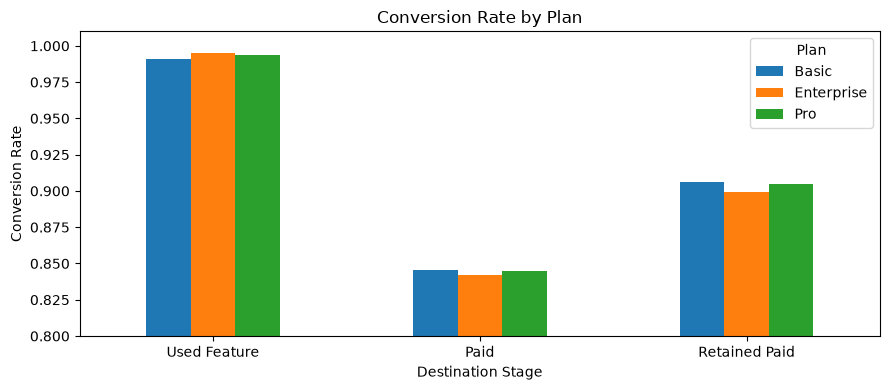


가장 낮은 조합: Enterprise - 유료 구독 도착
전환율: 84.19%
이탈률: 15.81%
개선 가설: Enterprise의 체험 구독과 비체험 구독에서 기능 사용 특성이 다르게 나타나는지 확인합니다.


In [ ]:
# 필수 2 코드를 작성하세요.
def calculate_segment_funnel(segment_ids, segment_name):
    segment_started = set(segment_ids)
    segment_used = segment_started & usage_ids
    segment_paid = segment_used & non_trial_ids
    segment_retained = segment_paid & not_ended_ids

    result = pd.DataFrame({
        "segment": segment_name,
        "stage": ["구독 시작", "기능 사용", "유료 구독", "현재 유료 유지"],
        "subscriptions": [
            len(segment_started), len(segment_used),
            len(segment_paid), len(segment_retained)]})
    result["conversion_rate"] = (result["subscriptions"] / result["subscriptions"].shift(1))
    result.loc[0, "conversion_rate"] = 1.0
    result["dropoff_rate"] = 1 - result["conversion_rate"]
    return result

plan_results = []
for plan in ["Basic", "Pro", "Enterprise"]:
    plan_ids = subscriptions.loc[
        subscriptions["plan_tier"] == plan,
        "subscription_id"]
    plan_results.append(calculate_segment_funnel(plan_ids, plan))

plan_funnel = pd.concat(plan_results, ignore_index=True)

print(plan_funnel.to_string(index=False, formatters={
    "subscriptions": lambda x: f"{x:,.0f}",
    "conversion_rate": lambda x: f"{x:.2%}",
    "dropoff_rate": lambda x: f"{x:.2%}"}))

plan_plot = (
    plan_funnel.loc[plan_funnel["stage"] != "구독 시작"]
    .pivot(index="stage", columns="segment", values="conversion_rate")
    .reindex(["기능 사용", "유료 구독", "현재 유료 유지"]))
plan_plot.index = ["Used Feature", "Paid", "Retained Paid"]

ax = plan_plot.plot(kind="bar", figsize=(9, 4), ylim=(0.80, 1.01))
ax.set_title("Conversion Rate by Plan")
ax.set_xlabel("Destination Stage")
ax.set_ylabel("Conversion Rate")
ax.legend(title="Plan")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

lowest_plan_row = (plan_funnel.loc[plan_funnel["stage"] != "구독 시작"].sort_values("conversion_rate").iloc[0])

print(f"\n가장 낮은 조합: {lowest_plan_row['segment']} - {lowest_plan_row['stage']} 도착")
print(f"전환율: {lowest_plan_row['conversion_rate']:.2%}")
print(f"이탈률: {lowest_plan_row['dropoff_rate']:.2%}")
print("개선 가설: Enterprise의 체험 구독과 비체험 구독에서 기능 사용 특성이 다르게 나타나는지 확인합니다.")

### 필수 2 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**
- **Q4.**

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 결제 주기별 퍼널 비교하기

#### 문제 설명

월간 결제 구독과 연간 결제 구독의 퍼널을 비교하여 상대적으로 전환율이 낮은 그룹과 구간을 찾으세요.

> 이 과제는 필수 2에서 만든 함수와 분석 절차를 `billing_frequency`에 동일하게 적용하는 문제입니다.

#### 요구사항

1. `calculate_segment_funnel()`을 사용하여 `monthly`, `annual`의 퍼널을 계산하세요.
2. 두 결과를 결합하여 `billing_funnel`을 만드세요.
3. 첫 단계를 제외한 구간 전환율을 결제 주기별 막대그래프로 시각화하세요.
4. 모든 결제 주기와 구간의 조합 중 전환율이 가장 낮은 조합을 찾으세요.
5. 해당 그룹과 구간에 대한 개선 가설을 한 가지 제안하세요.
6. 퍼널 결과만으로 원인을 확정할 수 없는 이유와 추가 확인할 데이터를 설명하세요.

#### 해석 질문

**Q1.** 전환율이 가장 낮은 결제 주기와 구간의 조합은 무엇인가요?  
**Q2.** 해당 구간의 전환율과 이탈률은 얼마인가요?  
**Q3.** 이 결과만으로 결제 주기가 이탈의 원인이라고 말할 수 있나요?

#### 제출 결과

- `billing_funnel` 결과
- 결제 주기별 전환율 그래프
- 우선 점검 대상과 개선 가설
- 분석의 한계와 추가 확인 데이터
- Q1~Q3 답변

In [ ]:
# 과제 1 코드를 작성하세요.

### 과제 1 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**

---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 실습의 퍼널 단계를 어떻게 정의했나요?
-> 구독 여부 -> 기능 사용 -> 유료 구독 -> 구독 유지(종료 DATE가 없는) <- 이렇게 4단계로 구분

2. 단계별 사용자 수 대신 어떤 식별자의 고유 개수를 사용했나요?
-> 구독자 ID의 고유값을 사용했다.

3. 전환율과 이탈률은 어떻게 계산했나요?
-> 현재 단계 구독 수를 이전 단계 구독 수로 나누어 전환율을 계산하고
-> 1에서 전환율을 빼서 이탈율을 계산

4. 전체 퍼널에서 가장 큰 문제가 나타난 구간은 어디였나요?
-> 기능 -> 유로 구독 약 84%의 전환율, 이탈율은 16%

5. 퍼널 분석 결과와 실제 원인을 왜 구분해야 하나요?
-> 퍼널은 어느 구간에서 사용자가 줄었는지는 보여주지만
-> 가격, 기능, 문의 등 어떤 요인이 원인이이었는 지 직접 알려주지는 않는다.